# Telecom Customer Churn Prediction
**Dataset:** IBM Telco Customer Churn (7,032 records, 21 features)  
**Models:** Random Forest · XGBoost  
**Goal:** Predict which telecom customers are likely to cancel their subscription

---

## Problem Statement
Customer churn is one of the most expensive problems a telecom company faces — acquiring a new customer costs 5–10x more than retaining an existing one. This project builds a classification model to flag customers who are at risk of churning, giving the business time to intervene before it's too late.

## What's Inside
1. Exploratory Data Analysis — understanding churn patterns across contract type, charges, and tenure  
2. Preprocessing — encoding categoricals, handling class imbalance  
3. Random Forest Classifier — baseline model  
4. XGBoost Classifier — improved churn recall using `scale_pos_weight`  

---

## 1. Imports

In [1]:
# Core data and visualisation libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load Data

In [2]:
# Load the Telco churn dataset
# Update the path if running locally
df = pd.read_csv(r"D:\Python\Random Forest Project\Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Overview

### 3.1 Shape & Data Types

In [4]:
# 7,032 rows · 21 columns · mix of object, int64, float64
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


17 object columns need encoding before modelling. `SeniorCitizen` is numeric but categorical in meaning.

### 3.2 Descriptive Statistics

In [29]:
# Summary stats for numeric columns only
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Total charges range from \$18 to \$8,684 (mean ≈ \$2,283). High variance — expected given the wide spread in tenure.

## 4. Null Value Check

In [38]:
# Confirm there are no missing values — dataset is clean
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

No missing values. No imputation needed.

## 5. Exploratory Data Analysis

### 5.1 Churn Class Distribution

<Axes: xlabel='Churn', ylabel='count'>

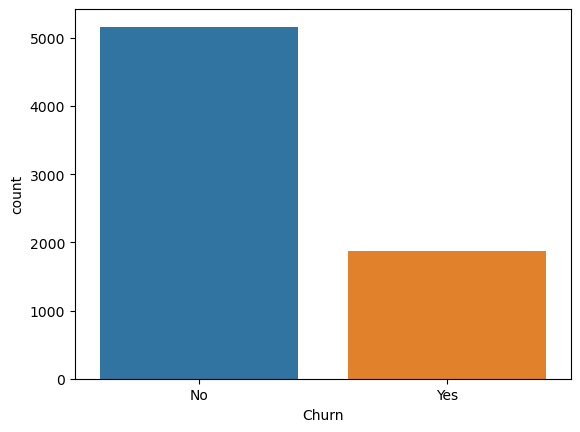

In [45]:
# Check for class imbalance — important for model evaluation
sns.countplot(x='Churn', data=df, hue='Churn')

The dataset is imbalanced: roughly **73% No / 27% Yes**. The model will naturally lean toward predicting 'No', so recall on churn cases will need close attention.

### 5.2 Total Charges vs Contract Type (Churn Split)

<Axes: xlabel='Contract', ylabel='TotalCharges'>

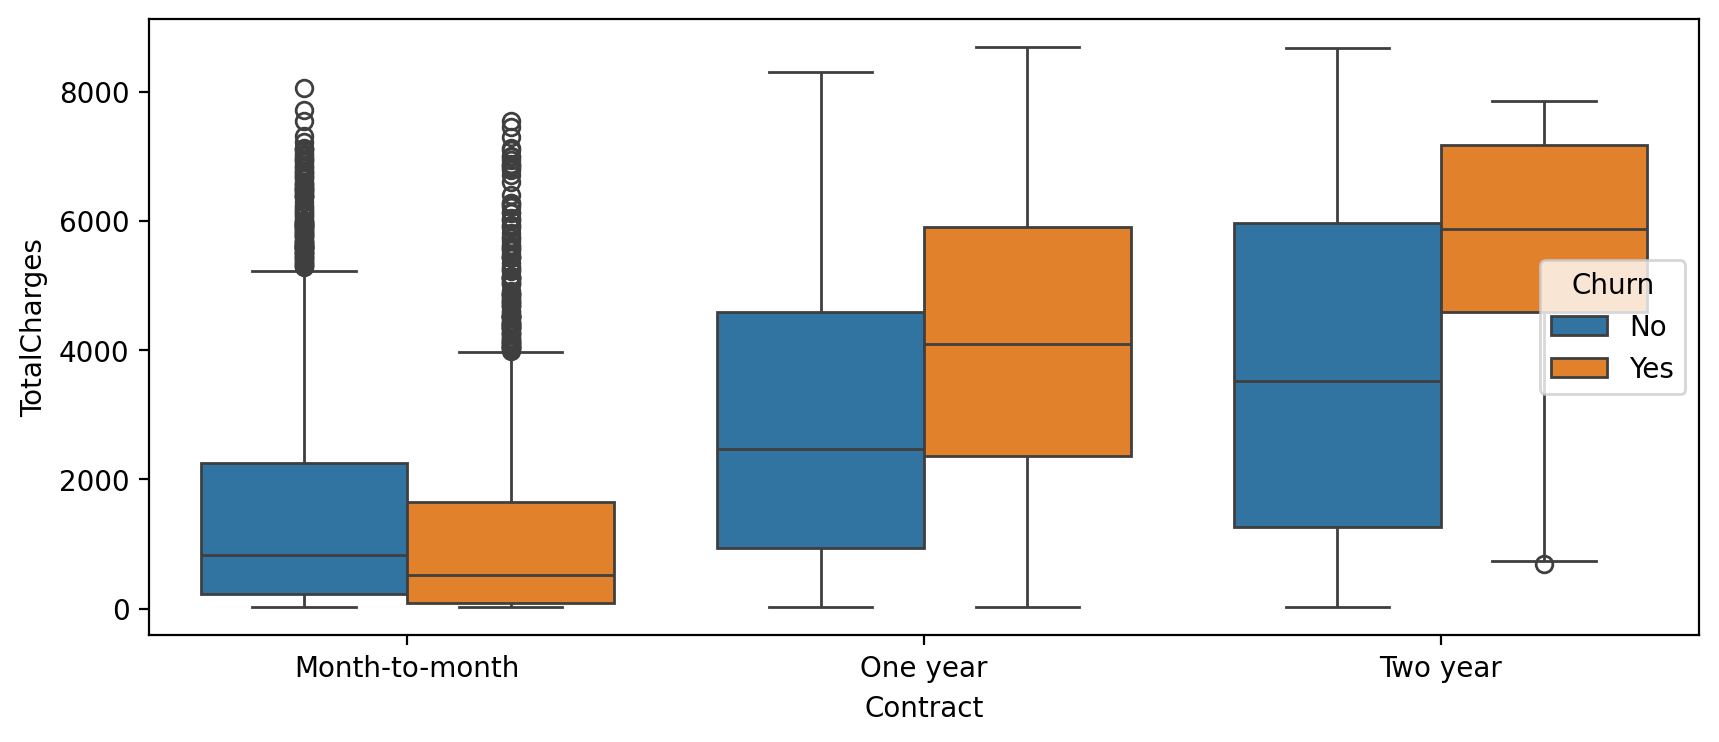

In [47]:
# Customers on longer contracts accumulate higher total charges
# Month-to-month churners leave before charges add up
sns.boxplot(data=df, y='TotalCharges', x='Contract', hue='Churn')

**Key insight:** Churned customers on month-to-month contracts have very low total charges, they leave quickly. Two-year contract churners actually paid more before leaving, suggesting they were satisfied longer but eventually found a reason to go.

### 5.3 Tenure Distribution by Contract Type

<Axes: xlabel='tenure', ylabel='Count'>

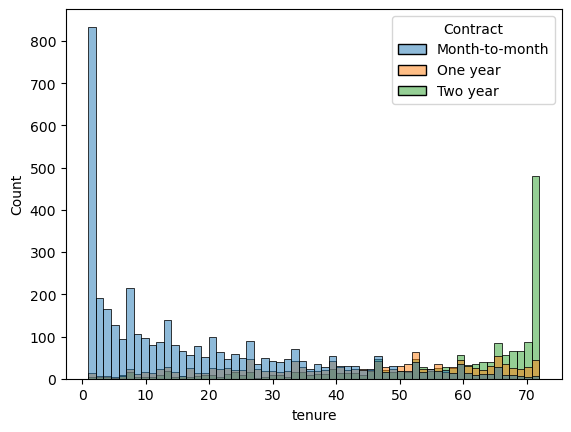

In [16]:
# Month-to-month customers dominate early tenure
# Two-year customers dominate at high tenure (loyal long-termers)
sns.histplot(data=df, x='tenure', hue='Contract')

Most new customers start on month-to-month. Those who stay long-term shift to two-year plans. One-year contracts are rarely chosen.

### 5.4 Monthly vs Total Charges (Churn Split)

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

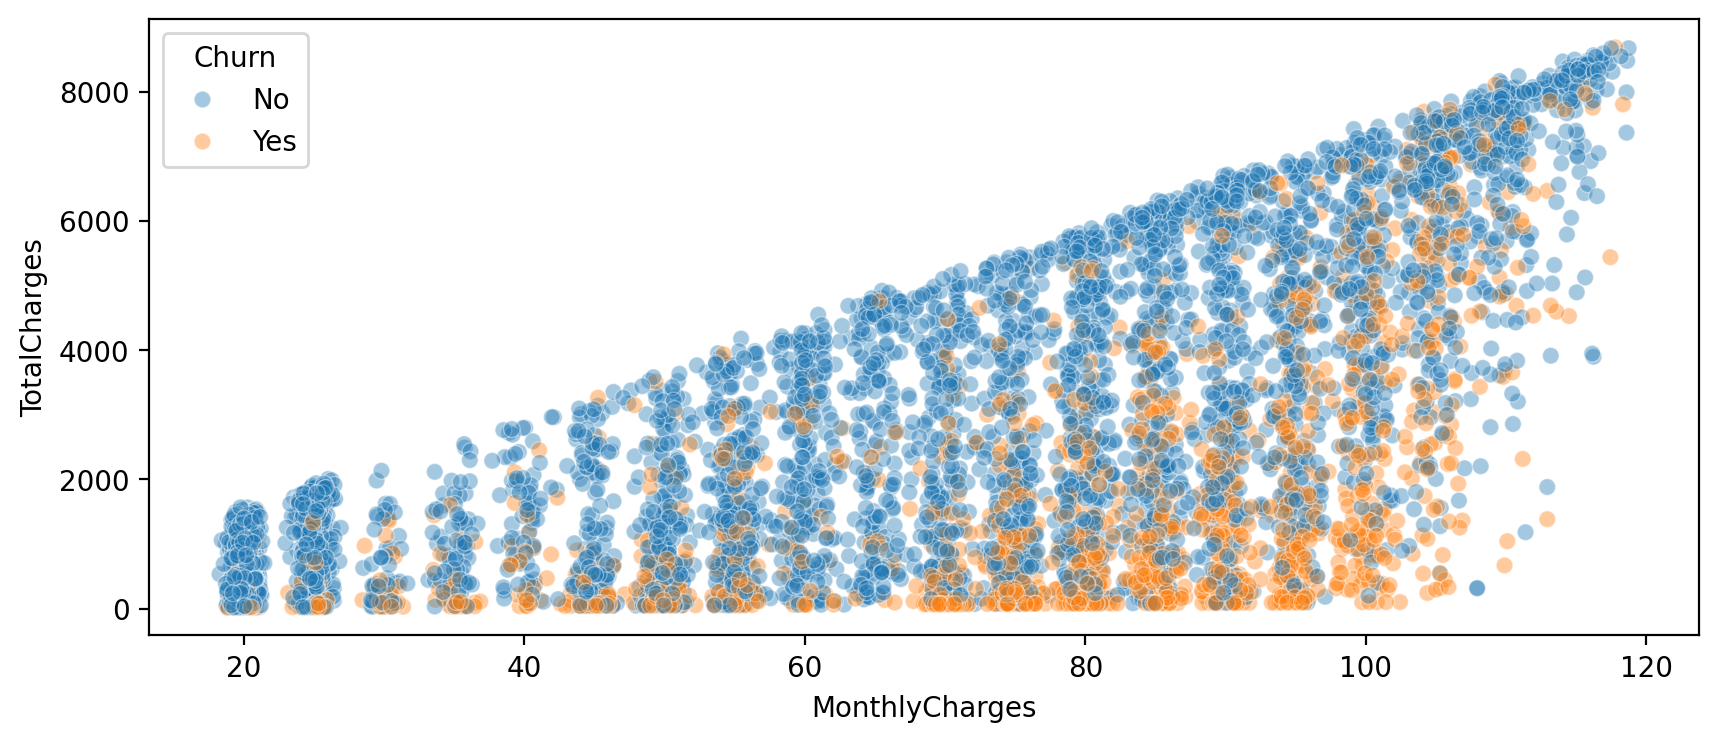

In [20]:
# High monthly charges + low total charges = recent churners
# High monthly + high total = retained high-value customers (protect these)
plt.figure(figsize=(10, 4), dpi=200)
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn', alpha=0.4)

The bottom-right cluster (high monthly, low total) is the target group — customers paying a lot but not staying long. These are the ones most worth retaining.

In [8]:
# Churn count by tenure — how many customers churned at each tenure length
yes_churn = df.groupby(['Churn', 'tenure']).count().transpose()['Yes']

In [25]:
# No-churn count by tenure
no_churn = df.groupby(['Churn', 'tenure']).count().transpose()['No']

## 6. Preprocessing

### 6.1 Define Features and Target

In [38]:
# Drop target column and customerID (identifier — no predictive value)
X = df.drop(['Churn', 'customerID'], axis=1)

### 6.2 Encode Categorical Features

In [39]:
# One-hot encode all categorical (object) columns
# drop_first=True removes one dummy per group to avoid multicollinearity
X = pd.get_dummies(X, drop_first=True)

In [40]:
# Target column — kept as string ('Yes'/'No')
# Random Forest handles string labels natively; XGBoost will need encoding later
y = df['Churn']

### 6.3 Train-Test Split

In [43]:
from sklearn.model_selection import train_test_split

# 90% train / 10% test — fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

## 7. Model 1 — Random Forest Classifier

Random Forest builds hundreds of decision trees independently, each trained on a random subset of rows and columns. Final prediction is determined by majority vote across all trees.

**Why Random Forest here?**  
- No feature scaling required  
- Handles mixed feature types well  
- Built-in feature importance scores  
- `class_weight='balanced'` used to compensate for the 73/27 class imbalance

In [49]:
from sklearn.ensemble import RandomForestClassifier

# class_weight='balanced' adjusts tree splits to give more weight to minority class (churners)
rf = RandomForestClassifier(class_weight='balanced')

In [ ]:
rf.fit(X_train, y_train)

In [51]:
preds = rf.predict(X_test)

### 7.1 Results

In [52]:
from sklearn.metrics import classification_report

In [53]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

          No       0.86      0.89      0.87       557
         Yes       0.52      0.44      0.48       147

    accuracy                           0.80       704
   macro avg       0.69      0.67      0.68       704
weighted avg       0.79      0.80      0.79       704



**Problem:** Only catching 44% of real churners (Recall = 0.44). Missing more than half the customers who are about to leave, it is a costly gap for the business.

**Root cause:** Class imbalance. The model saw ~3.8x more 'No' examples than 'Yes' during training.

## 8. Model 2 — XGBoost Classifier

XGBoost (Extreme Gradient Boosting) builds trees **sequentially** — each tree corrects the errors of the previous one. Unlike Random Forest's independent voting, XGBoost learns from its own mistakes at every step.

**Why XGBoost over Random Forest here?**  
- scale_pos_weight explicitly tells the model how imbalanced the classes are  
- Generally outperforms Random Forest on tabular data  
- Handles missing values automatically  
- Regularization built in (less overfitting)

In [55]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [56]:
from xgboost import XGBClassifier

### 8.1 Handle Class Imbalance

In [59]:
# Calculate the No:Yes ratio to pass into scale_pos_weight
# This tells XGBoost to treat each churner as ~3.8x more important during training
no_count = (y_train == 'No').sum()
yes_count = (y_train == 'Yes').sum()
ratio = no_count / yes_count
print(f'Class ratio (No:Yes) = {ratio:.2f}')

### 8.2 Encode Target for XGBoost

In [63]:
from sklearn.preprocessing import LabelEncoder

# XGBoost requires numeric labels — encode No=0, Yes=1
le = LabelEncoder()

In [65]:
y_train_enc = le.fit_transform(y_train)  # fit on train, transform train
y_test_enc = le.transform(y_test)         # only transform test — no fitting

### 8.3 Train XGBoost

In [72]:
xgb = XGBClassifier(
    scale_pos_weight=2,   # upweights churners — tuned down from raw ratio of ~3.8 to balance precision/recall
    n_estimators=200,     # 200 sequential trees
    learning_rate=0.1,    # step size per tree — smaller = more careful, needs more trees
    max_depth=4,          # max depth of each tree — controls complexity
    random_state=101
)

In [ ]:
xgb.fit(X_train, y_train_enc)

### 8.4 Results

In [74]:
xgb_preds = xgb.predict(X_test)
print(classification_report(y_test_enc, xgb_preds))

              precision    recall  f1-score   support

           0       0.90      0.80      0.85       557
           1       0.47      0.68      0.55       147

    accuracy                           0.77       704
   macro avg       0.69      0.74      0.70       704
weighted avg       0.81      0.77      0.79       704



## 9. Model Comparison & Conclusion

| Metric | Random Forest | XGBoost |
|---|---|---|
| Churn F1 | 0.48 | **0.55** |
| Churn Recall | 0.44 | **0.68** |
| Churn Precision | 0.52 | 0.47 |
| Overall Accuracy | **0.80** | 0.77 |

**Winner: XGBoost** for this use case.

In churn prediction, **recall matters more than precision** : missing a customer who churns costs more than a false alarm. XGBoost catches 68% of real churners vs Random Forest's 44%, a significant improvement that translates directly to business value.

The slight drop in overall accuracy is an acceptable tradeoff for catching significantly more at-risk customers before they leave.